<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Mastering_Advanced_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Mastering Advanced Data Visualization: The Lollipop Chart**

### নোটবুক পরিচিতি (Metadata)

* **Aim:** `msleep` ডাটাসেট ব্যবহার করে স্তন্যপায়ী প্রাণীদের ঘুমের অভ্যাসের একটি প্রফেশনাল ভিজ্যুয়ালাইজেশন তৈরি করা।
* **Key Skills:** Layering (Geometry), Theme Customization (Dark Mode), Annotations, এবং Color Gradients।
* **Concept:** এই টিউটোরিয়ালে আমরা শিখব কীভাবে লেয়ার বাই লেয়ার কোড যোগ করে একটি সাধারণ প্লটকে "আর্ট"-এ রূপান্তর করা যায়।

---

#### ডাটাসেট পরিচিতি (Description)

এই ডাটাসেটটিতে ৮৩টি স্তন্যপায়ী প্রাণীর ঘুমের ধরণ এবং তাদের শারীরিক ওজন ও ব্রেন ওজনের তথ্য রয়েছে। এটি মূলত একটি ইকো-ফিজিওলজিক্যাল ডাটাসেট।

#### ভ্যারিয়েবল ডিকশনারি (Variable Dictionary)

| কলামের নাম (Variable) | বিবরণ (Description) |
| --- | --- |
| **`name`** | প্রাণীর সাধারণ নাম (Common name)। |
| **`genus`** | প্রাণীর ট্যাক্সোনমিক গণ (Taxonomic rank)। |
| **`v_vore`** | খাদ্যতালিকাগত ধরণ (যেমন: carni - মাংসাশী, herbi - তৃণভোজী, omni - সর্বভোজী)। |
| **`order`** | প্রাণীর বর্গ বা অর্ডার (Taxonomic order)। |
| **`conservation`** | সংরক্ষণের অবস্থা (যেমন: lc - least concern, en - endangered)। |
| **`sleep_total`** | ২৪ ঘণ্টায় মোট ঘুমের পরিমাণ (ঘণ্টায়)। |
| **`sleep_rem`** | REM (Rapid Eye Movement) ঘুমের পরিমাণ (ঘণ্টায়)। |
| **`sleep_cycle`** | ঘুমের চক্রের দৈর্ঘ্য (ঘণ্টায়)। |
| **`awake`** | ২৪ ঘণ্টায় জেগে থাকার মোট সময় (ঘণ্টায়)। |
| **`brainwt`** | মস্তিষ্কের ওজন (কিলোগ্রামে)। |
| **`bodywt`** | শরীরের মোট ওজন (কিলোগ্রামে)। |

---

#### কেন এই ডাটাসেটটি জনপ্রিয়?

* **রিলেশনশিপ অ্যানালাইসিস:** শরীরের ওজন বাড়লে কি ঘুমের পরিমাণ কমে? এই ধরণের কোরিলেশন (Correlation) শেখার জন্য এটি সেরা।
* **ক্যাটেগরিক্যাল ডেটা:** প্রাণীদের খাবার অভ্যাস (`vore`) এবং সংরক্ষণের অবস্থা (`conservation`) দিয়ে দারুণ বার চার্ট তৈরি করা যায়।
* **মিসিং ভ্যালু হ্যান্ডলিং:** এই ডাটাসেটে বেশ কিছু `NA` ভ্যালু আছে, যা ডেটা ক্লিনিং শেখার জন্য খুব উপযোগী।


In [24]:
# ডাটাসেট লোড করা
library(ggplot2)
data(msleep)

In [25]:
# ডাটাসেটের স্ট্রাকচার দেখা
str(msleep)

tibble [83 × 11] (S3: tbl_df/tbl/data.frame)
 $ name        : chr [1:83] "Cheetah" "Owl monkey" "Mountain beaver" "Greater short-tailed shrew" ...
 $ genus       : chr [1:83] "Acinonyx" "Aotus" "Aplodontia" "Blarina" ...
 $ vore        : chr [1:83] "carni" "omni" "herbi" "omni" ...
 $ order       : chr [1:83] "Carnivora" "Primates" "Rodentia" "Soricomorpha" ...
 $ conservation: chr [1:83] "lc" NA "nt" "lc" ...
 $ sleep_total : num [1:83] 12.1 17 14.4 14.9 4 14.4 8.7 7 10.1 3 ...
 $ sleep_rem   : num [1:83] NA 1.8 2.4 2.3 0.7 2.2 1.4 NA 2.9 NA ...
 $ sleep_cycle : num [1:83] NA NA NA 0.133 0.667 ...
 $ awake       : num [1:83] 11.9 7 9.6 9.1 20 9.6 15.3 17 13.9 21 ...
 $ brainwt     : num [1:83] NA 0.0155 NA 0.00029 0.423 NA NA NA 0.07 0.0982 ...
 $ bodywt      : num [1:83] 50 0.48 1.35 0.019 600 ...


In [26]:
# প্রধান পরিসংখ্যান (Summary Statistics)
summary(msleep[, c("sleep_total", "awake", "bodywt", "brainwt")])

  sleep_total        awake           bodywt            brainwt       
 Min.   : 1.90   Min.   : 4.10   Min.   :   0.005   Min.   :0.00014  
 1st Qu.: 7.85   1st Qu.:10.25   1st Qu.:   0.174   1st Qu.:0.00290  
 Median :10.10   Median :13.90   Median :   1.670   Median :0.01240  
 Mean   :10.43   Mean   :13.57   Mean   : 166.136   Mean   :0.28158  
 3rd Qu.:13.75   3rd Qu.:16.15   3rd Qu.:  41.750   3rd Qu.:0.12550  
 Max.   :19.90   Max.   :22.10   Max.   :6654.000   Max.   :5.71200  
                                                    NA's   :27       

### ১. এনভায়রনমেন্ট সেটআপ এবং ডেটা প্রসেসিং (Env Setup & Data Processing)

প্রথমে প্রয়োজনীয় লাইব্রেরি লোড করে ডেটাকে একটু গুছিয়ে নিই। আমরা `order` অনুযায়ী গড় ঘুম (`mean_sleep`) বের করব।

In [27]:
library(tidyverse)

#### ১.১ গ্রুপিং এবং সামারি (Grouping & Summarising)
আমরা group_by(order) ব্যবহার করে প্রাণীদের শ্রেণী অনুযায়ী ভাগ করেছি এবং summarise() এর মাধ্যমে প্রতিটি শ্রেণীর গড় ঘুমের পরিমাণ (mean_sleep) বের করেছি।

In [28]:
# ডেটা প্রিপারেশন
sleep_data <- msleep %>%
  group_by(order) %>%
  summarise(mean_sleep = mean(sleep_total))

#### ২. ফ্যাক্টর রিঅর্ডারিং (Factor Reordering)
ভিজ্যুয়ালাইজেশনের সময় বার চার্ট বা অন্য কোনো গ্রাফকে সুন্দরভাবে সাজানোর জন্য fct_reorder() ব্যবহার করা হয়েছে। এটি ঘুমের গড় মানের ওপর ভিত্তি করে ক্যাটাগরিগুলোকে ছোট থেকে বড় ক্রমে সাজাবে।

In [29]:
# ডেটা প্রিপারেশন
sleep_data <- msleep %>%
  group_by(order) %>%
  summarise(mean_sleep = mean(sleep_total)) %>%
  mutate(order = fct_reorder(order, mean_sleep)) # ঘুমের মান অনুযায়ী সাজানো

## ২. ধাপে ধাপে প্লট তৈরি (Step-by-Step Evolution)

### ধাপ ১: বেসিক ক্যানভাস এবং লেবেল (The Canvas)

শুরুতেই আমরা ঠিক করি X এবং Y অক্ষে কী থাকবে এবং টাইটেল কী হবে।

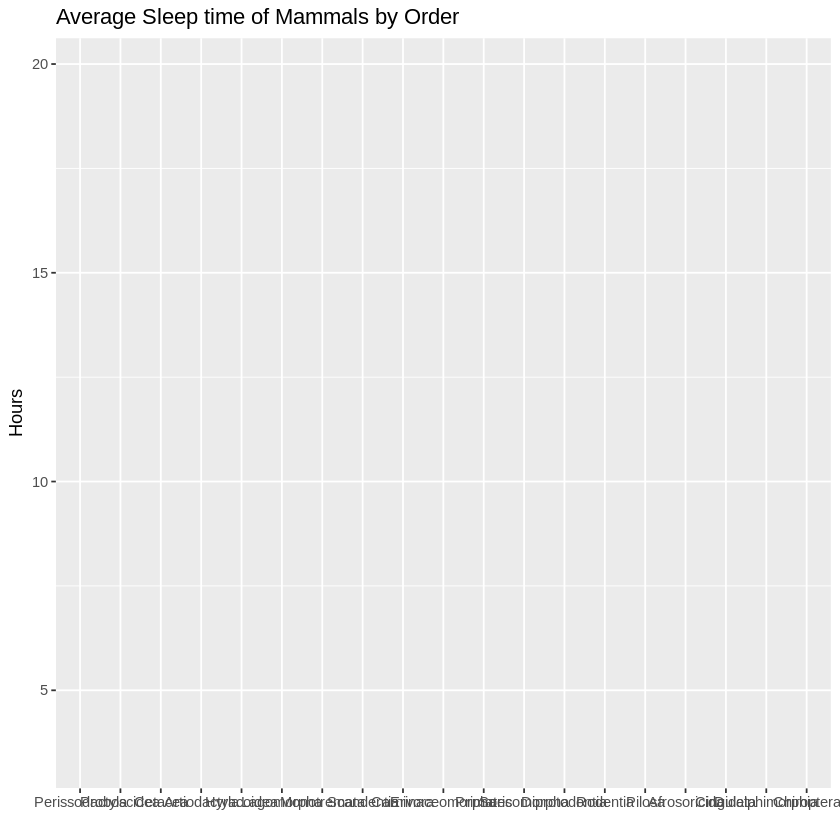

In [30]:
plot_step1 <- sleep_data %>%
  ggplot(aes(order, mean_sleep)) +
  labs(title = "Average Sleep time of Mammals by Order",
       x = "",
       y = "Hours")

plot_step1

### ধাপ ২: কাস্টম থিম এবং ডার্ক মোড (Styling)

এখন আমরা ব্যাকগ্রাউন্ড কালো করব এবং টেক্সটগুলোর রঙ পরিবর্তন করে একটি নিয়ন ভাইব (Neon Vibe) দেব।

#### ধাপ ২.১: অক্ষের লেবেল বিন্যাস (Axis Labels Style)
এই ধাপে আমরা X এবং Y অক্ষের টেক্সটের রঙ পরিবর্তন করব। বিশেষভাবে X-অক্ষের নামগুলোকে ৪৫° অ্যাঙ্গেলে বাঁকিয়ে দেব যাতে সেগুলো পরিষ্কার দেখা যায়।

* axis.text.x    এটি X-অক্ষের লেবেলগুলোর (যেমন: বারের নাম বা সংখ্যা) স্টাইল পরিবর্তন করে। এখানে আপনি টেক্সটকে ৪৫° অ্যাঙ্গেলে বাঁকিয়েছেন।
* axis.text.y	এটি Y-অক্ষের লেবেলগুলোর স্টাইল (রঙ, সাইজ ইত্যাদি) পরিবর্তন করে।

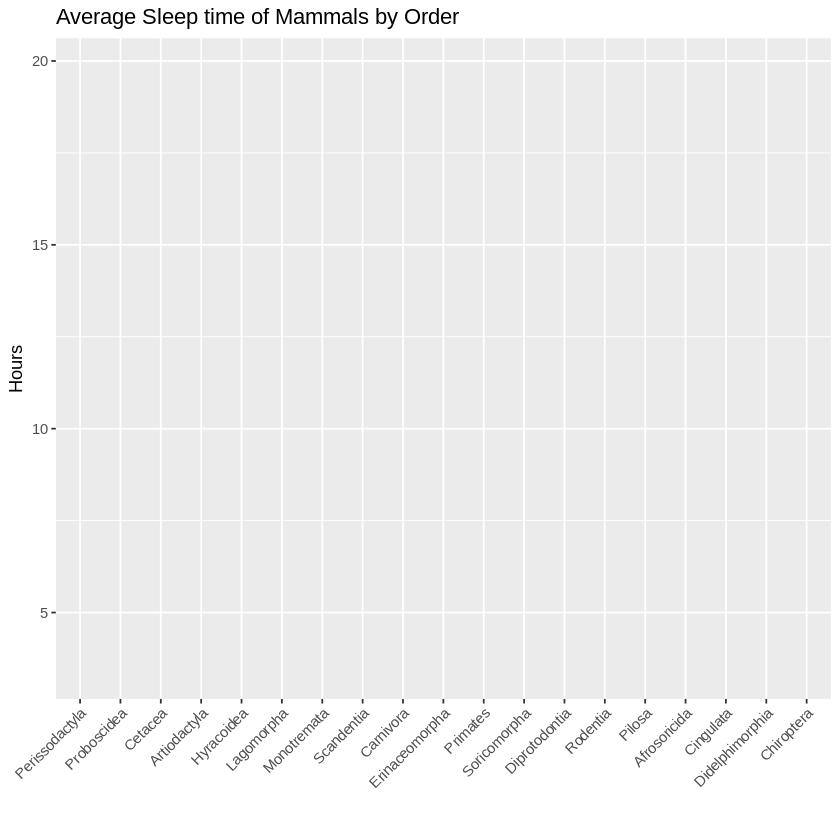

In [31]:
# X-অক্ষের নামগুলোকে ৪৫° অ্যাঙ্গেলে বাঁকিয়ে দেব

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1))

plot_step2

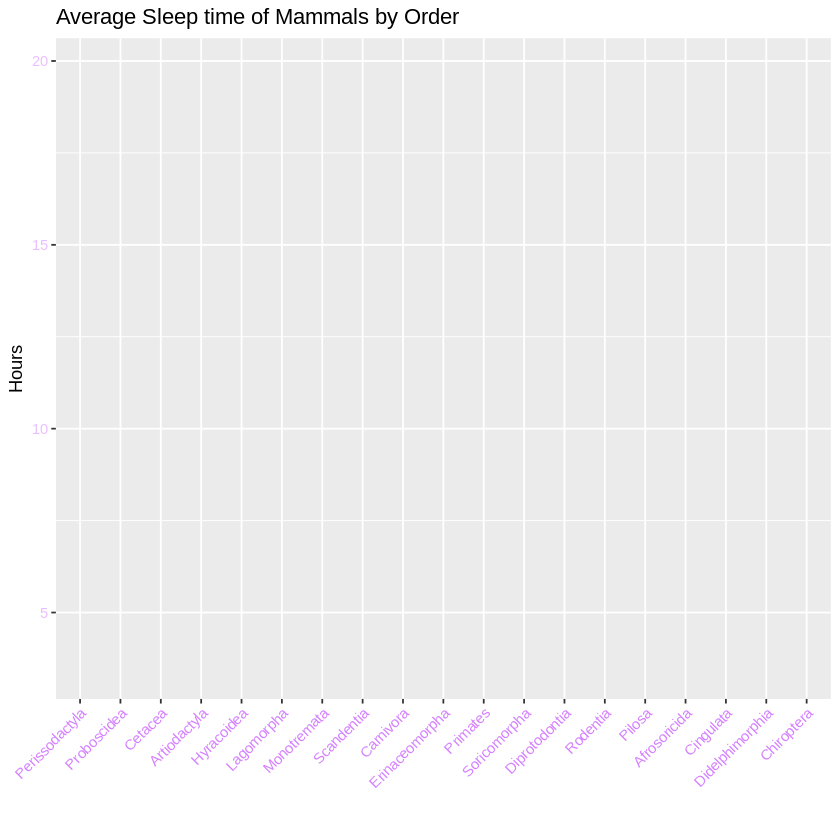

In [32]:
# এবার X-অক্ষের নামগুলোকে একটি নির্দিষ্ট হেক্সকোডে কালার করবো।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff")
  )

plot_step2

**note:** এখন X-অক্ষের নামগুলোকে ভালোভাবে দেখা যাচ্ছে না, তবে কালো ব্যাকগ্রাউন্ডে ফুটে উঠবে।

#### ধাপ ২.২: শিরোনাম এবং অক্ষের টাইটেল (Title & Axis Title Style)
গ্রাফের মূল শিরোনাম (Main Title) এবং অক্ষের টাইটেলকে আকর্ষণীয় ও বোল্ড করার জন্য এই অংশটি কাজ করে।

* axis.title.y	Y-অক্ষের টাইটেল বা নাম (যেমন: "Count" বা "Price") কেমন দেখাবে তা নির্ধারণ করে।
* plot.title	গ্রাফের প্রধান শিরোনাম বা টাইটেলের ডিজাইন (রঙ, বোল্ডনেস, সাইজ) ঠিক করে।


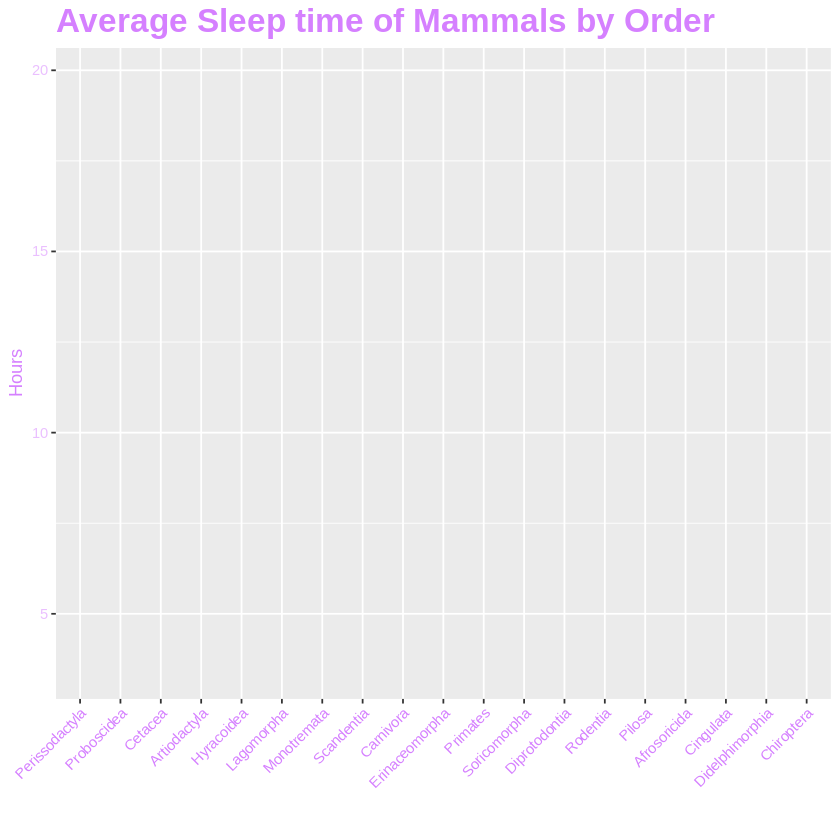

In [33]:
plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20)
  )

plot_step2

#### ধাপ ২.৩: অক্ষরেখা এবং টিক মার্ক (Axis Lines & Ticks Style)
অক্ষরেখা এবং এর ওপরের ছোট ছোট দাগগুলোকে একটি নির্দিষ্ট নিওন কালার দেওয়ার জন্য এটি ব্যবহৃত হয়।

* axis.line	    X এবং Y অক্ষের যে মূল রেখা বা লাইন থাকে, তার রঙ এবং পুরুত্ব পরিবর্তন করে।
* axis.ticks	অক্ষের ওপর যে ছোট ছোট দাগ (Ticks) থাকে, সেগুলোর ডিজাইন পরিবর্তন করে।

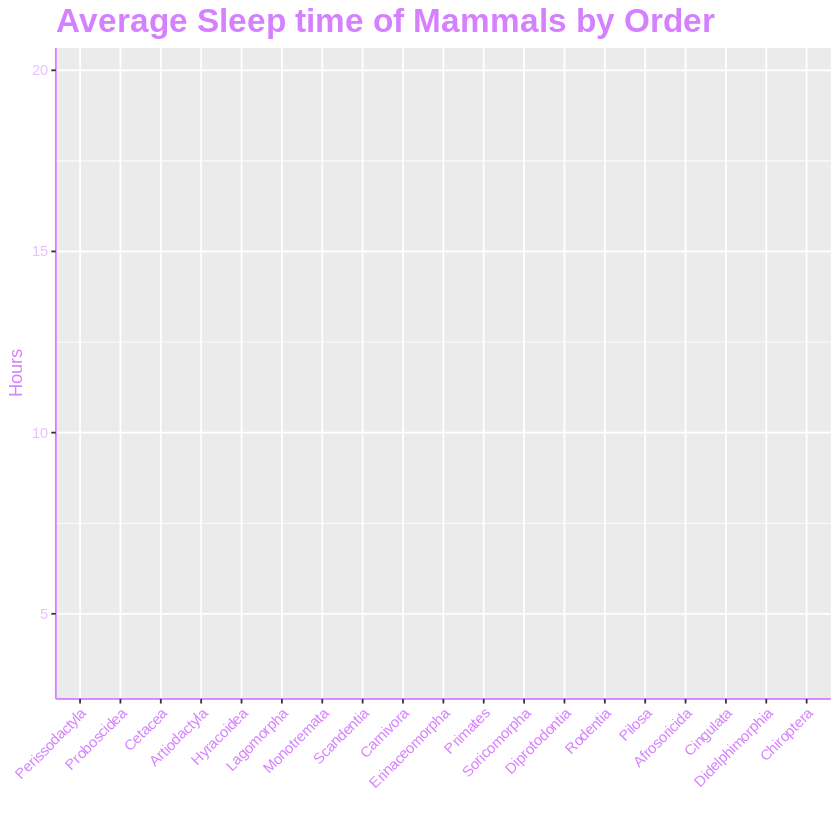

In [34]:
# axis.line	  X এবং Y অক্ষের যে মূল রেখা বা লাইন থাকে, তার রঙ এবং পুরুত্ব পরিবর্তন করে।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff")
  )

plot_step2

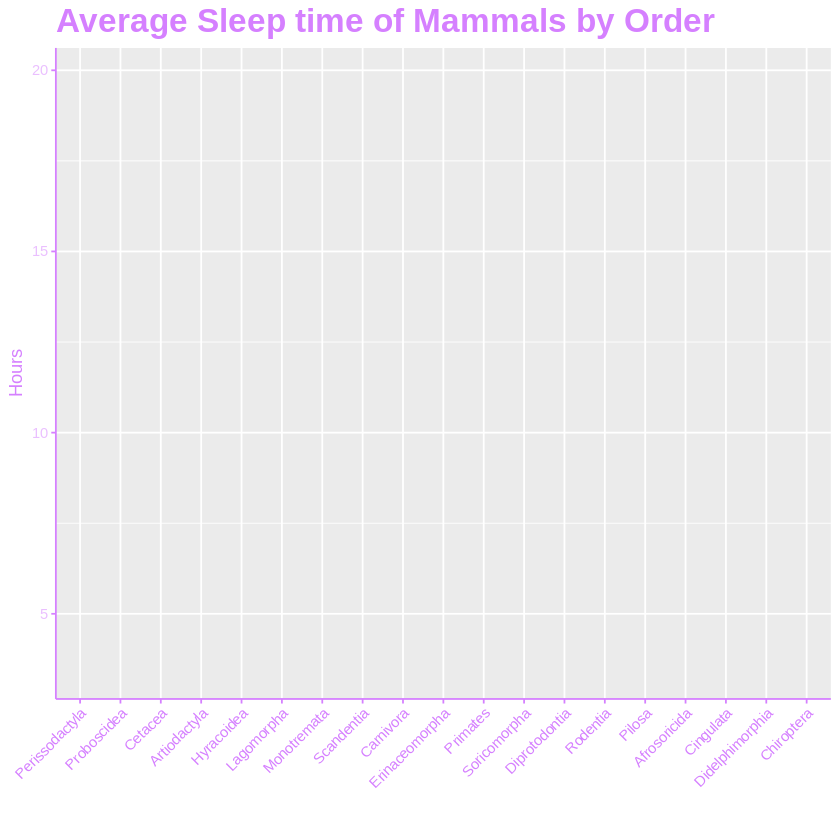

In [35]:
# axis.ticks   অক্ষের ওপর যে ছোট ছোট দাগ (Ticks) থাকে, সেগুলোর ডিজাইন পরিবর্তন করে।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff"),
    axis.ticks = element_line(color = "#d580ff")
  )

plot_step2

#### ধাপ ২.৪: ব্যাকগ্রাউন্ড বা পটভূমি (Background Colors)
পুরো গ্রাফটিকে ডার্ক বা ব্ল্যাক থিম দেওয়ার জন্য panel.background এবং plot.background দুটোই কালো করা হয়েছে

* panel.background	যেখানে ডেটা প্লট করা হয় (অর্থাৎ গ্রাফের ভেতরের অংশ), তার ব্যাকগ্রাউন্ড কালার ঠিক করে।
* plot.background	পুরো গ্রাফের একদম বাইরের বা চারদিকের ব্যাকগ্রাউন্ড কালার পরিবর্তন করে।

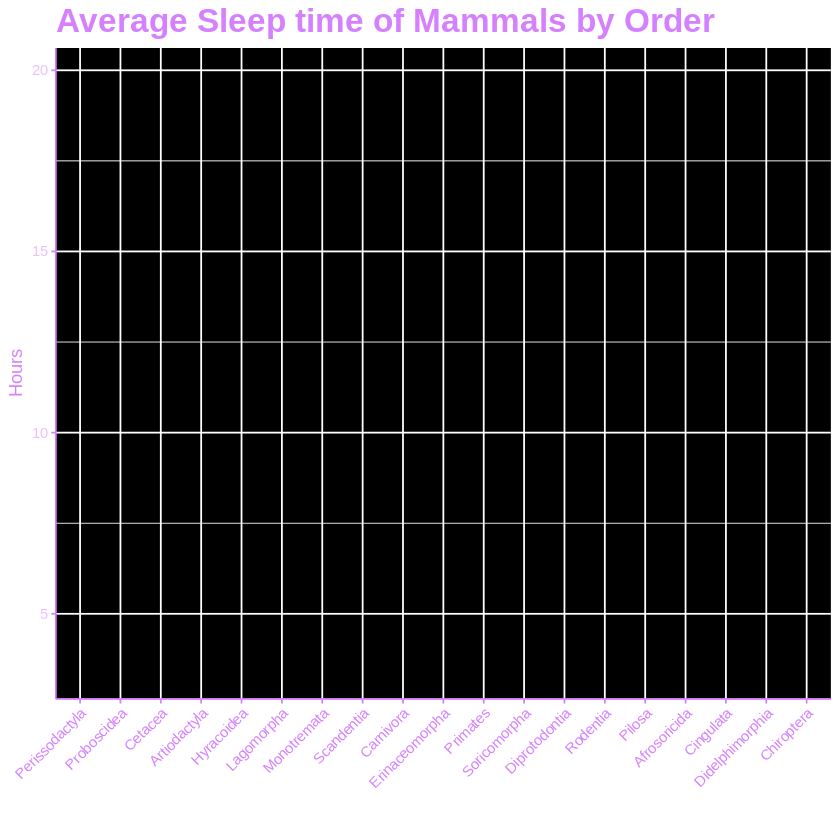

In [36]:

# panel.background	যেখানে ডেটা প্লট করা হয় (অর্থাৎ গ্রাফের ভেতরের অংশ),
# তার ব্যাকগ্রাউন্ড কালার ঠিক করে।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff"),
    axis.ticks = element_line(color = "#d580ff"),
    panel.background = element_rect(fill = "black")
  )

plot_step2

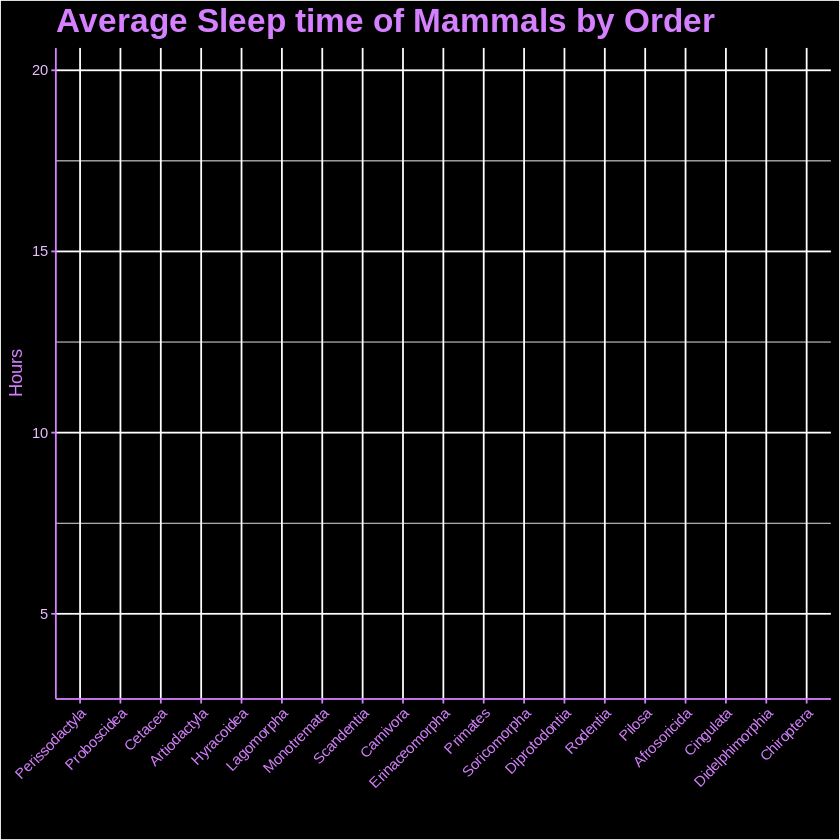

In [37]:
# plot.background	পুরো গ্রাফের একদম বাইরের বা চারদিকের ব্যাকগ্রাউন্ড কালার পরিবর্তন করে।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff"),
    axis.ticks = element_line(color = "#d580ff"),
    panel.background = element_rect(fill = "black"),
    plot.background = element_rect(fill = "black")
  )

plot_step2

#### ধাপ ২.৫: গ্রিড লাইন পরিষ্কার করা (Cleaning Grids)
গ্রাফকে আরও ক্লিন এবং আধুনিক দেখাতে পেছনের সব গ্রিড লাইন এবং পাশের লেজেন্ড রিমুভ করে দেওয়া হয়েছে।

* panel.grid.major	গ্রাফের পেছনের প্রধান গ্রিড লাইনগুলো (বড় ঘরগুলো) নিয়ন্ত্রণ করে। এখানে element_blank() দিয়ে এগুলো মুছে ফেলা হয়েছে।
* panel.grid.minor	গ্রাফের পেছনের ছোট বা minor গ্রিড লাইনগুলো নিয়ন্ত্রণ করে। এটিও এখানে মুছে ফেলা হয়েছে।

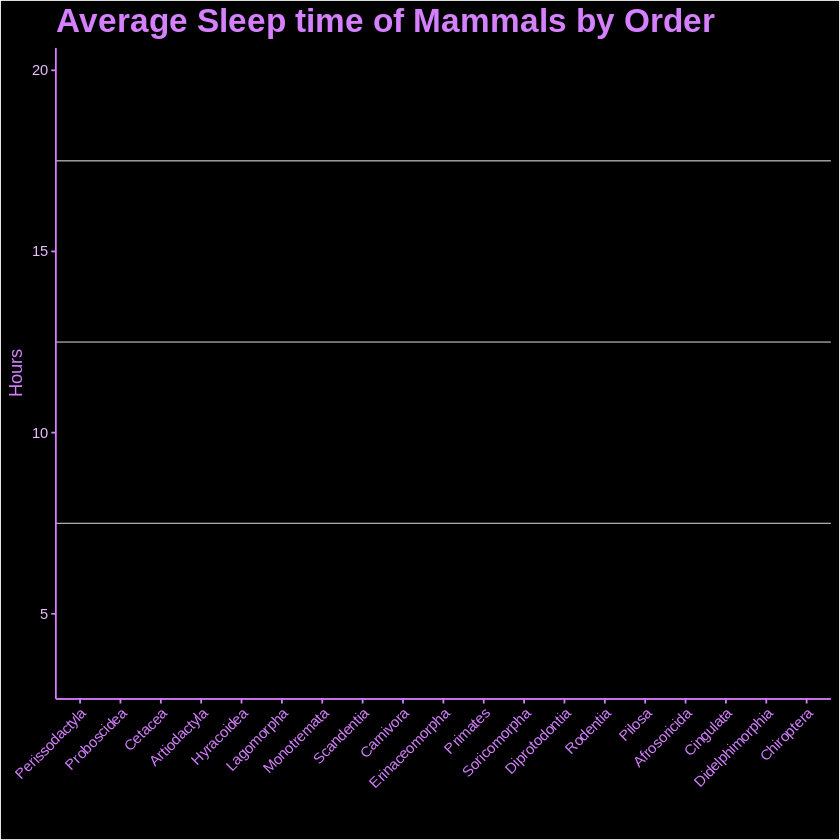

In [38]:
# panel.grid.major	গ্রাফের পেছনের প্রধান গ্রিড লাইনগুলো (বড় ঘরগুলো) নিয়ন্ত্রণ করে।
# এখানে element_blank() দিয়ে এগুলো মুছে ফেলা হয়েছে।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff"),
    axis.ticks = element_line(color = "#d580ff"),
    panel.background = element_rect(fill = "black"),
    plot.background = element_rect(fill = "black"),
    panel.grid.major = element_blank()
  )

plot_step2

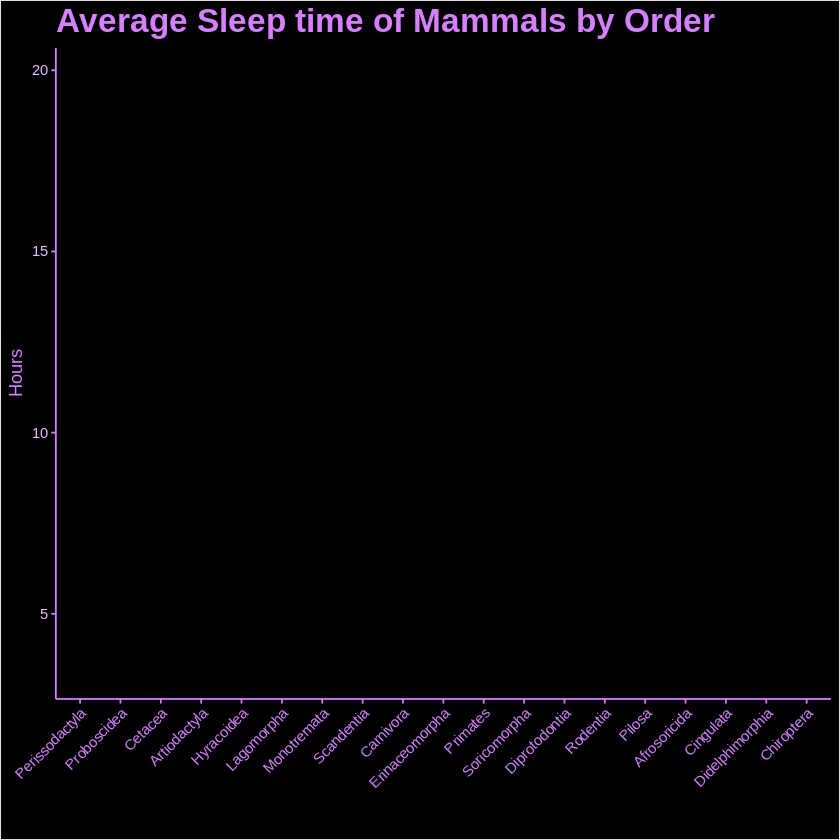

In [39]:
# panel.grid.minor	গ্রাফের পেছনের ছোট বা minor গ্রিড লাইনগুলো নিয়ন্ত্রণ করে।
# এটিও এখানে মুছে ফেলা হয়েছে।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff"),
    axis.ticks = element_line(color = "#d580ff"),
    panel.background = element_rect(fill = "black"),
    plot.background = element_rect(fill = "black"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

plot_step2

#### ধাপ ২.৬: লেজেন্ড (Legend) পরিষ্কার করা (Cleaning Legend positioning)


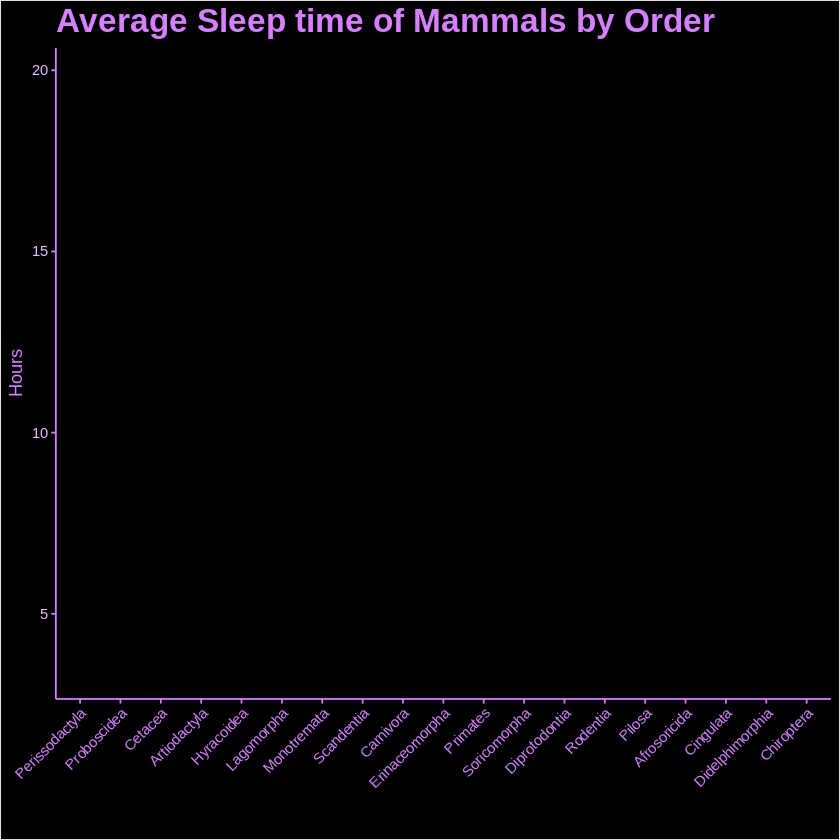

In [40]:
# legend.position	লেজেন্ড (Legend) কোথায় থাকবে তা ঠিক করে।
# এখানে "none" মানে কোনো লেজেন্ড দেখাবে না।

plot_step2 <- plot_step1 +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1, color = "#d580ff"),
    axis.text.y = element_text(color = "#eabfff"),
    axis.title.y = element_text(color = "#d580ff"),
    plot.title = element_text(color = "#d580ff", face = "bold", size = 20),
    axis.line = element_line(color = "#d580ff"),
    axis.ticks = element_line(color = "#d580ff"),
    panel.background = element_rect(fill = "black"),
    plot.background = element_rect(fill = "black"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "none"
  )

plot_step2

### ধাপ ৩: রেফারেন্স লাইন এবং কানেক্টিং স্টিকস (The Lollipop Base)

গড় ঘুমের একটি বেঞ্চমার্ক লাইন এবং প্রতিটি পয়েন্টের জন্য স্টিক বা ডান্ডি যোগ করা।

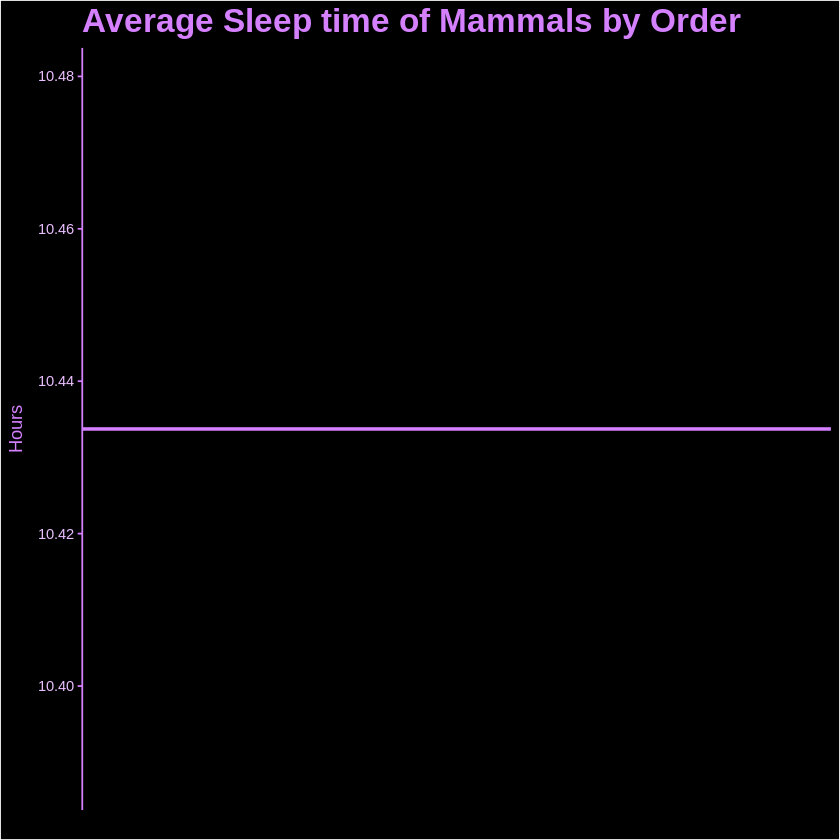

In [41]:
plot_step3 <- plot_step2 +
  # সব প্রাণীর গড় ঘুমের একটি অনুভূমিক রেখা
  geom_hline(yintercept = mean(msleep$sleep_total),
             color = "#d580ff", size = 1)

plot_step3

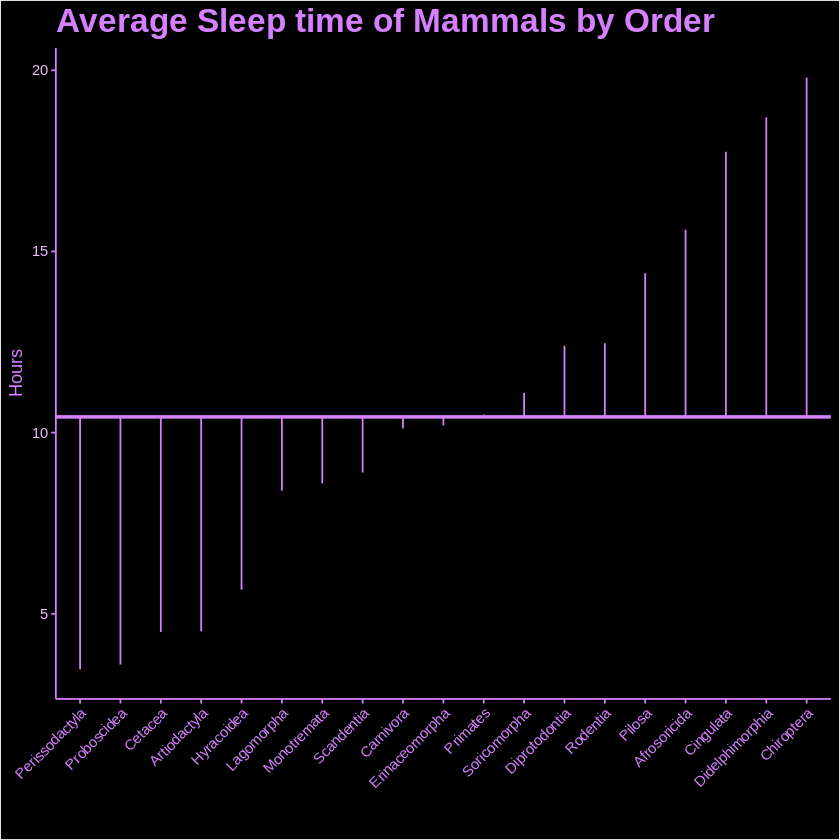

In [42]:
plot_step3 <- plot_step2 +
  # সব প্রাণীর গড় ঘুমের একটি অনুভূমিক রেখা
  geom_hline(yintercept = mean(msleep$sleep_total),
             color = "#d580ff", size = 1) +
  # মেইন লাইন থেকে প্রতিটি পয়েন্টের দূরত্ব বোঝাতে সেগমেন্ট
  geom_segment(aes(x = order,
                   y = mean(msleep$sleep_total),
                   xend = order,
                   yend = mean_sleep),
               color = "#d580ff")

plot_step3

### ধাপ ৪: কালার গ্রেডিয়েন্ট পয়েন্ট যোগ করা (Adding Points)

এখন ডান্ডিগুলোর মাথায় রঙিন বিন্দু দেব যা ঘুমের পরিমাণ অনুযায়ী রঙ বদলাবে।

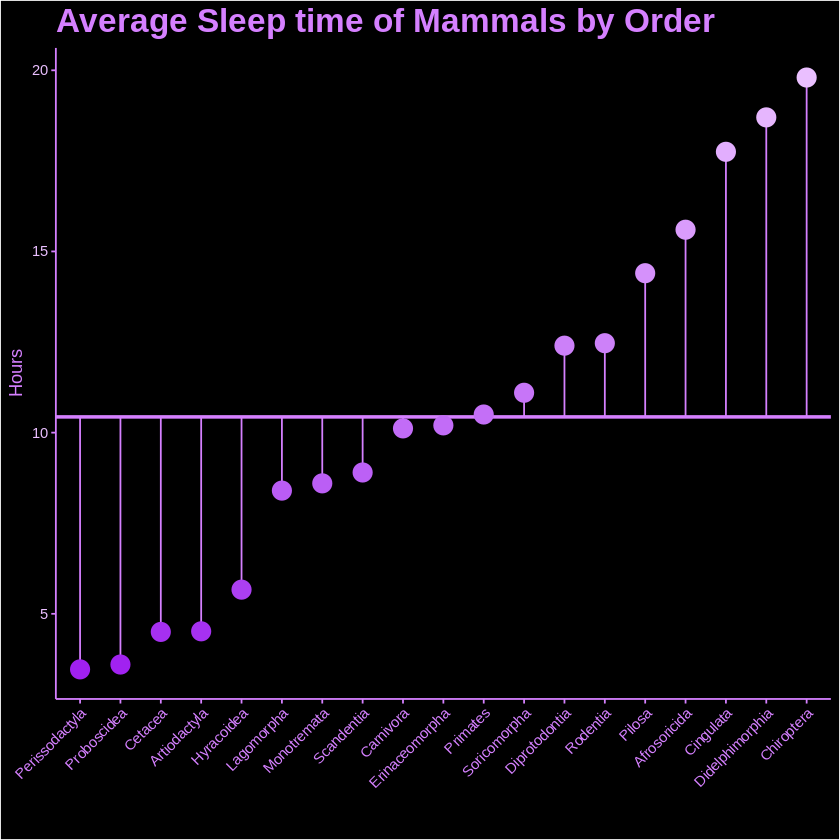

In [43]:
plot_step4 <- plot_step3 +
  geom_point(aes(color = mean_sleep), size = 5) +
  scale_color_gradient(low = "purple", high = "#eabfff")

plot_step4

### ধাপ ৫: অ্যানোটেশন এবং অ্যারো (The Final Touch)

গ্রাফটিকে আরও ব্যাখ্যামূলক করার জন্য আমরা একটি টেক্সট এবং অ্যারো (Arrow) যোগ করব।

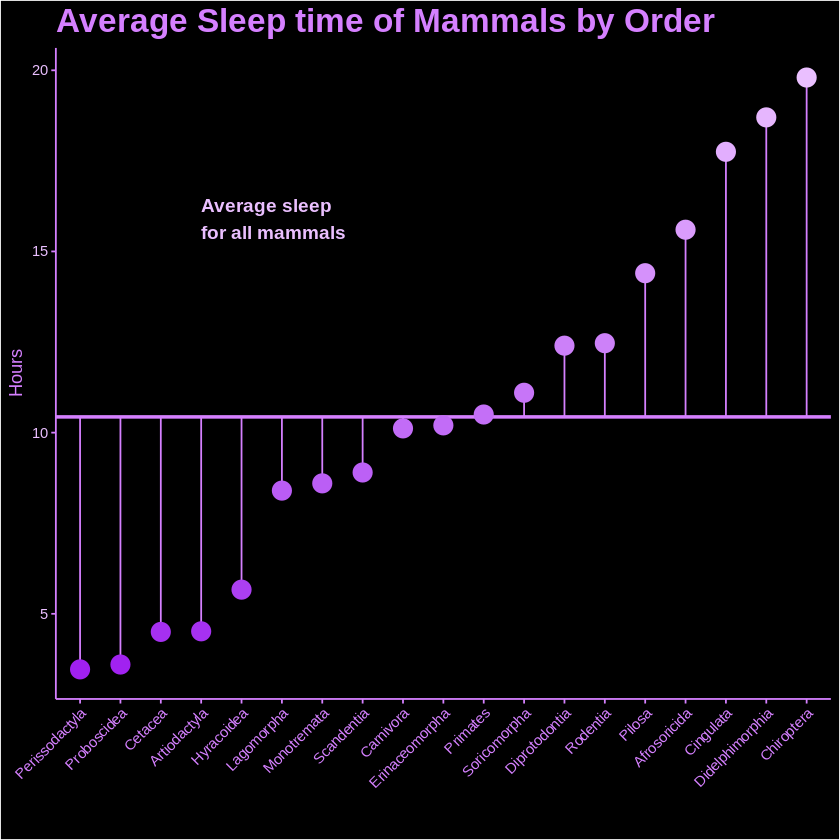

In [44]:
final_plot <- plot_step4 +
  # টেক্সট যোগ করা
  annotate("text", x = 4, y = max(msleep$sleep_total) - 4,
           label = "Average sleep\nfor all mammals",
           color = "#eabfff", size = 4, fontface = "bold", hjust = 0)

final_plot

Warning message in geom_curve(aes(x = 3.7, y = max(msleep$sleep_total) - 5, xend = 1.5, :
“All aesthetics have length 1, but the data has 19 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


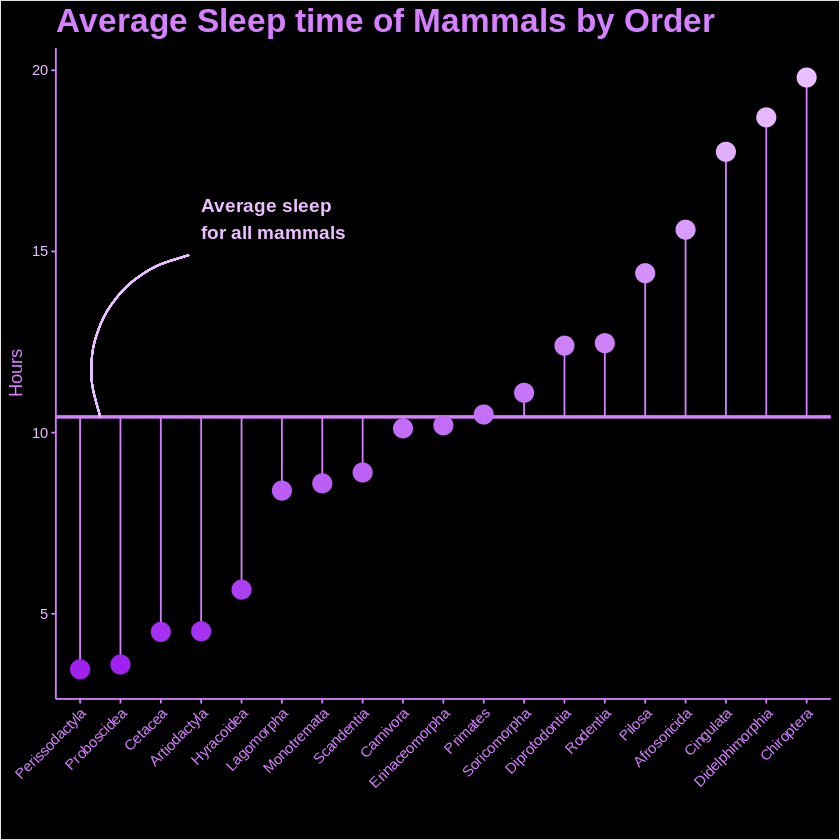

In [45]:
final_plot <- plot_step4 +
  # টেক্সট যোগ করা
  annotate("text", x = 4, y = max(msleep$sleep_total) - 4,
           label = "Average sleep\nfor all mammals",
           color = "#eabfff", size = 4, fontface = "bold", hjust = 0) +
  # বক্ররেখা অ্যারো যোগ করা
  geom_curve(aes(x = 3.7, y = max(msleep$sleep_total) - 5,
                 xend = 1.5, yend = mean(msleep$sleep_total)),
             color = "#eabfff", curvature = 0.5)

final_plot

Warning message in geom_curve(aes(x = 3.7, y = max(msleep$sleep_total) - 5, xend = 1.5, :
“All aesthetics have length 1, but the data has 19 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.”


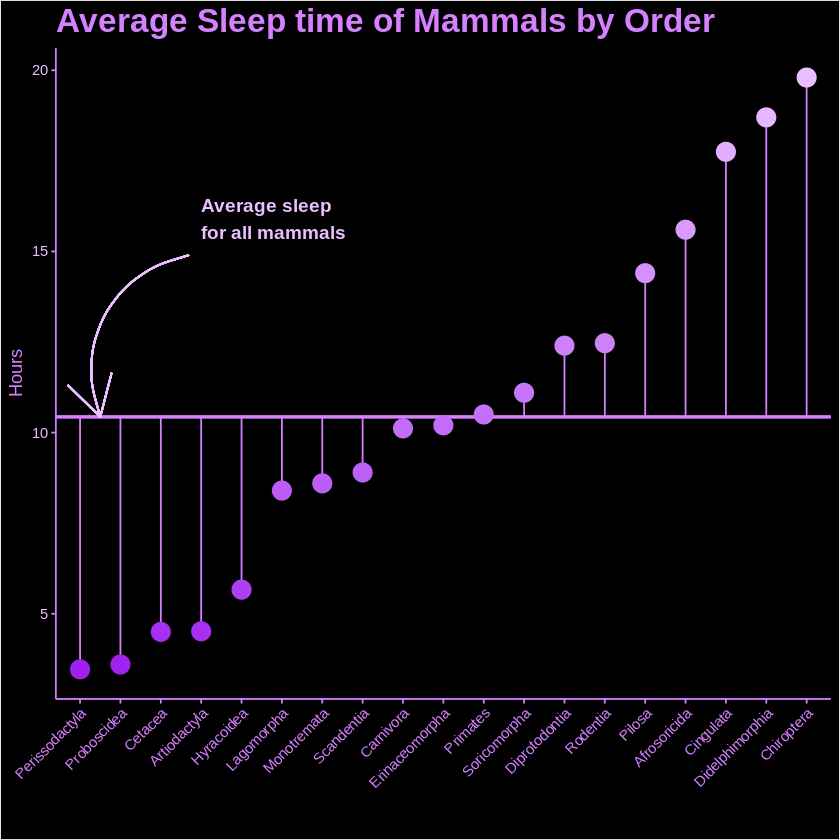

In [46]:
final_plot <- plot_step4 +
  # টেক্সট যোগ করা
  annotate("text", x = 4, y = max(msleep$sleep_total) - 4,
           label = "Average sleep\nfor all mammals",
           color = "#eabfff", size = 4, fontface = "bold", hjust = 0) +
  # বক্ররেখা অ্যারো যোগ করা
  geom_curve(aes(x = 3.7, y = max(msleep$sleep_total) - 5,
                 xend = 1.5, yend = mean(msleep$sleep_total)),
             color = "#eabfff", curvature = 0.5,
             arrow = arrow(length = unit(0.07, "npc"), type = "open"))

final_plot

### এক নজরে আপনার শেখা টুলকিট (Cheat Sheet):

* **`fct_reorder()`**: ক্যাটাগরিগুলোকে ভ্যালু অনুযায়ী সাজাতে ব্যবহৃত হয়।
* **`theme(panel.background = ...)`**: গ্রাফের ব্যাকগ্রাউন্ড কাস্টমাইজ করতে।
* **`geom_segment()`**: ললিপপ চার্টের 'কাঠি' বা স্টিক তৈরি করতে।
* **`geom_curve()` & `annotate()`**: গ্রাফের নির্দিষ্ট অংশকে হাইলাইট বা ব্যাখ্যা করতে।
* **`scale_color_gradient()`**: কন্টিনিউয়াস ডেটার জন্য রঙের পরিবর্তন দেখাতে।

---

**অভিনন্দন!** আপনি একটি সাধারণ প্লটকে হাই-এন্ড ভিজ্যুয়ালাইজেশনে রূপান্তর করেছেন।